In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import pandapower as pp
from pathlib import Path
import json
import numba
import time

In [2]:

KABEL_PATH  = "data\\netz_excels\\kabel_excel.xlsx"
KNOTEN_PATH = "data\\netz_excels\\knoten_excel.xlsx"
PARAMS_PATH = "data\\netz_excels\\kabel_parameter.csv"


kabel  = pd.read_excel(KABEL_PATH, index_col=0)
knoten = pd.read_excel(KNOTEN_PATH, index_col=0)
params = pd.read_csv(PARAMS_PATH)


In [3]:
net = pp.create_empty_network(f_hz=50, sn_mva=10)

for idx, row in knoten.iterrows():
    pp.create_bus(net, vn_kv=0.4, name=row["IDENTNUMME"], index=idx)

print(net.bus)


          name  vn_kv type  zone  in_service   geo
0   6B0402-302    0.4    b  None        True  None
1   6B0402-041    0.4    b  None        True  None
3   6B0402-125    0.4    b  None        True  None
4   6B4100-003    0.4    b  None        True  None
5   6B0402-209    0.4    b  None        True  None
6   6B0402-043    0.4    b  None        True  None
7   6B0402-037    0.4    b  None        True  None
8   6B0402-017    0.4    b  None        True  None
9   6B0402-272    0.4    b  None        True  None
10  6B0402-282    0.4    b  None        True  None
11  6B0402-318    0.4    b  None        True  None
12  6B0402-320    0.4    b  None        True  None
13  6B0402-324    0.4    b  None        True  None
14  6B0402-328    0.4    b  None        True  None
15  6B0402-332    0.4    b  None        True  None
16  6B0402-334    0.4    b  None        True  None
17  6B0402-336    0.4    b  None        True  None
19  6B0402-270    0.4    b  None        True  None
20  6B0402-103    0.4    b  Non

In [4]:
netzstation = knoten[knoten["KNOTENTYP"] == "NETZSTATION"]
slack_idx = netzstation.index[0]

pp.create_ext_grid(
    net,
    bus  = slack_idx,
    vm_pu = 1.0,
    name = knoten.loc[slack_idx, "IDENTNUMME"]
)
# Neuer HV-Bus (Mittelspannungsseite)
bus_ms = pp.create_bus(net, vn_kv=20.0, name="MS_Sammelschiene")

# ext_grid auf MS-Bus verschieben
net.ext_grid.loc[0, "bus"] = bus_ms

# Trafo anlegen (630 kVA, Standardwerte ONT)
pp.create_transformer_from_parameters(
    net,
    hv_bus=bus_ms,
    lv_bus=1,  # Bus 1 = Netzstation NS-Seite
    sn_mva=0.63,
    vn_hv_kv=20.0,
    vn_lv_kv=0.4,
    vkr_percent=1.1,
    vk_percent=4.0,
    pfe_kw=1.3,
    i0_percent=0.27,
    name="ONT_630kVA"
)
print(net.ext_grid)

         name  bus  vm_pu  va_degree  slack_weight  in_service  controllable
0  6B0402-041   45    1.0        0.0           1.0        True         False


In [5]:
params_dict = {
    (row["kabeltyp"], row["adern"], row["querschnitt_mm2"]): (
        row["r_ohm_per_km"],
        row["x_ohm_per_km"],
        row["c_nf_per_km"],
        row["max_i_ka"]
    )
    for _, row in params.iterrows()
}

# Leitungen anlegen
keine_params = []

for idx, row in kabel.iterrows():
    key = (row["KABELTYP"], row["ADERN"], row["QUERSCHNIT"])

    if key not in params_dict:
        keine_params.append(key)
        continue

    r, x, c, imax = params_dict[key]

    pp.create_line_from_parameters(
        net,
        from_bus     = row["start_bus"],
        to_bus       = row["end_bus"],
        length_km    = row["length_m"] / 1000,
        r_ohm_per_km = r,
        x_ohm_per_km = x,
        c_nf_per_km  = c,
        max_i_ka     = imax,
        name         = f"Kabel_{idx}"
)

if keine_params:
    print(f"⚠ Keine Parameter für: {set(keine_params)}")
else:
    print(net.line)



        name std_type  from_bus  to_bus  length_km  r_ohm_per_km  \
0    Kabel_0     None         0      33   0.020941         1.150   
1    Kabel_1     None         1      20   0.031199         0.206   
2    Kabel_3     None         3       1   0.018862         0.206   
3    Kabel_4     None         1      26   0.008117         0.206   
4    Kabel_5     None         4       1   0.120900         0.206   
5    Kabel_6     None         5      22   0.062805         0.443   
6    Kabel_7     None         7      35   0.021956         0.253   
7    Kabel_8     None         1       6   0.034085         0.206   
8    Kabel_9     None         9      31   0.017520         1.870   
9   Kabel_10     None        10      35   0.076792         0.868   
10  Kabel_11     None        11      36   0.061731         0.868   
11  Kabel_12     None        12      37   0.017808         0.320   
12  Kabel_13     None        13      38   0.025279         0.868   
13  Kabel_14     None        14      38   0.0126

In [6]:
datetime_index = pd.date_range(start="2018-01-01", end="2018-12-31 23:00", freq="h")

#Platzhalter DF
with open("data/gebaudelasten/gebauedelasten.json", "r") as f:
    load_data = json.load(f)

load_df = pd.DataFrame(load_data, index=datetime_index)

#print(load_df.shape)
#print(load_df.head())

t = 0
timestep = load_df.iloc[t]

for col in load_df.columns:
    bus_idx = int(col.split("_")[1])
    p_mw   = timestep[col] / 1000  # kW -> MW

    pp.create_load(
        net,
        bus    = bus_idx,
        p_mw   = p_mw,
        q_mvar = 0.0,
        name   = f"Last_{bus_idx}"
    )



In [9]:
# Spitzenlast finden und Lastfluss berechnen
gesamtlast = load_df.sum(axis=1)  # Summe aller Profile pro Zeitschritt
t_peak = gesamtlast.idxmax()      # Zeitpunkt der maximalen Gesamtlast

print(f"Spitzenlast-Zeitpunkt: {t_peak}")
print(f"Gesamtlast: {gesamtlast[t_peak]:.2f} kW")

# Spitzenlast-Zeitschritt
timestep = load_df.loc[t_peak]

# Lasten im Netz aktualisieren
for col in load_df.columns:
    bus_idx = int(col.split("_")[1])
    p_mw    = timestep[col] / 1000  # kW -> MW

    net.load.loc[net.load["bus"] == bus_idx, "p_mw"] = p_mw

# Lastfluss berechnen
pp.runpp(net, algorithm="nr", numba=False)

print(f"✅ Lastfluss konvergiert für {t_peak}")
print(f"\nBus-Spannungen:")
print(net.res_bus[["vm_pu"]].sort_values("vm_pu"))
print(f"\nLeitungsauslastung:")
print(net.res_line[["loading_percent"]].sort_values("loading_percent", ascending=False))
print(f"Trafo-Auslastung: {net.res_trafo['loading_percent'].values[0]:.1f}%")

Spitzenlast-Zeitpunkt: 2018-11-16 21:00:00
Gesamtlast: 167.44 kW
✅ Lastfluss konvergiert für 2018-11-16 21:00:00

Bus-Spannungen:
       vm_pu
4   0.987306
34  0.989913
6   0.993898
17  0.994022
24  0.994250
10  0.994262
23  0.994334
16  0.994358
22  0.994359
27  0.994369
8   0.994403
29  0.994403
41  0.994403
36  0.994404
11  0.994404
39  0.994608
15  0.994630
13  0.994772
28  0.994811
14  0.994826
5   0.994838
38  0.994905
9   0.995138
32  0.995305
0   0.995496
12  0.995532
31  0.995549
37  0.995611
44  0.995744
40  0.995744
35  0.995790
33  0.995800
30  0.995842
43  0.995851
7   0.995957
19  0.996211
20  0.996559
1   0.996916
26  0.996916
3   0.996916
25  0.996916
45  1.000000

Leitungsauslastung:
    loading_percent
30        36.059569
29        36.059569
7         36.059568
4         32.382119
42         8.200325
41         7.030710
40         6.087902
16         5.195026
1          4.666909
35         4.666908
8          4.606713
15         4.352165
9          4.305573
0         

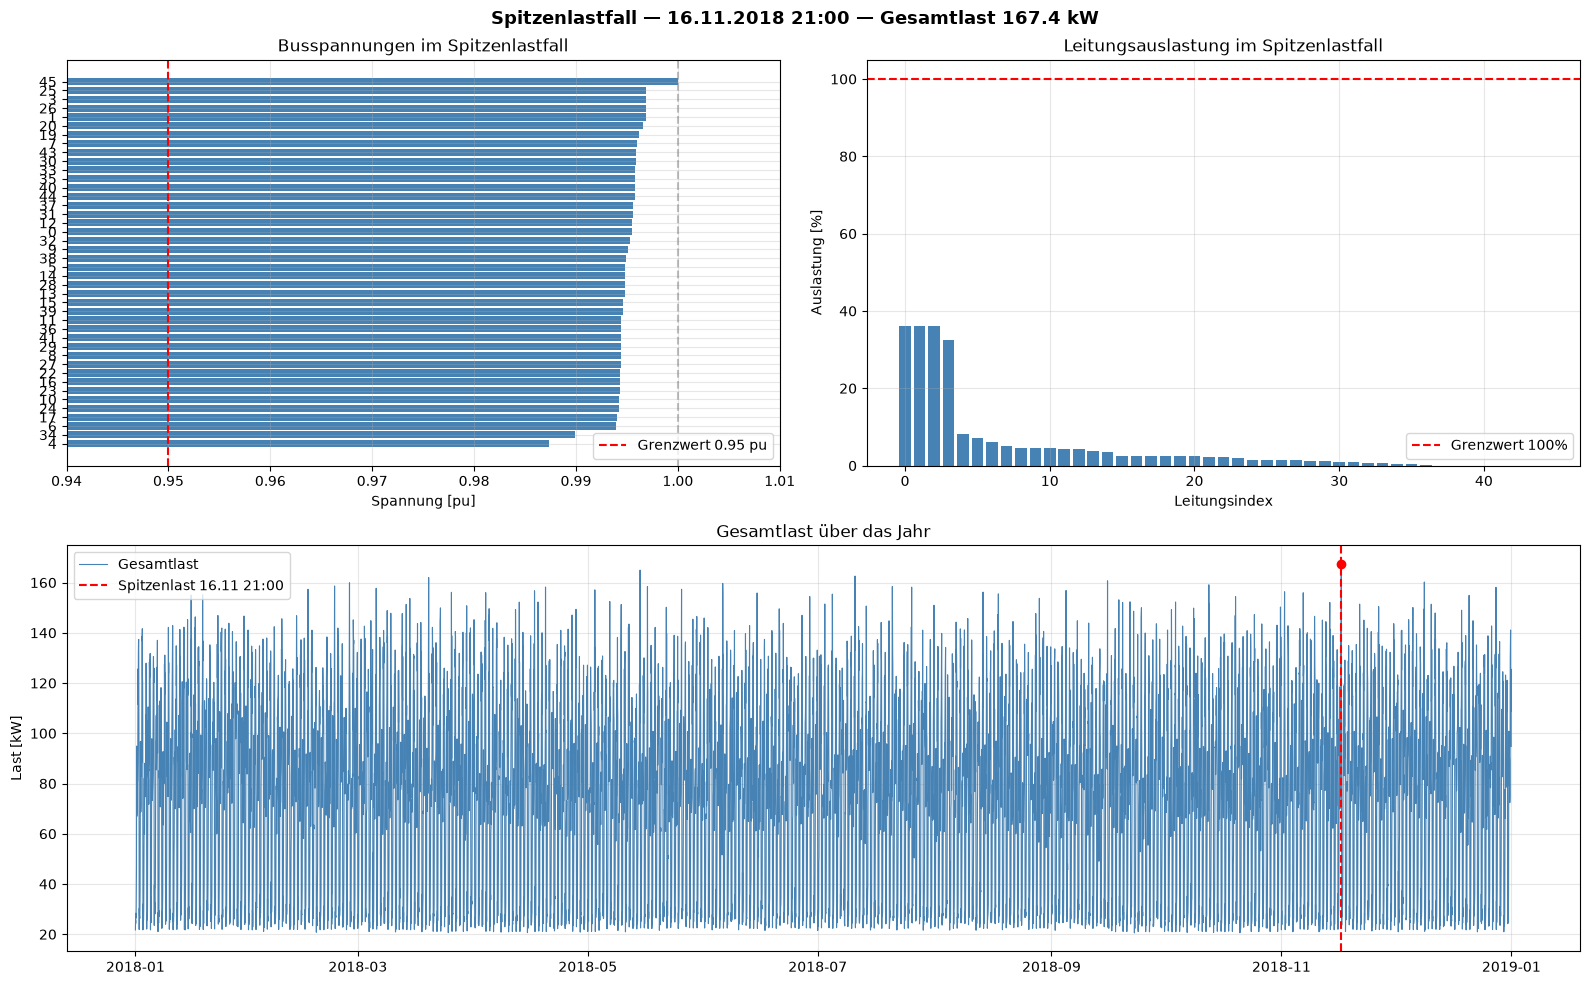

In [8]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# --- Plot 1: Busspannungen (Balken) ---
ax1 = fig.add_subplot(gs[0, 0])
vm = net.res_bus["vm_pu"].sort_values()
farben = ["red" if v < 0.95 else "orange" if v < 0.97 else "steelblue" for v in vm]
ax1.barh(vm.index.astype(str), vm.values, color=farben)
ax1.axvline(0.95, color="red", linestyle="--", label="Grenzwert 0.95 pu")
ax1.axvline(1.0, color="gray", linestyle="--", alpha=0.5)
ax1.set_xlabel("Spannung [pu]")
ax1.set_title("Busspannungen im Spitzenlastfall")
ax1.legend()
ax1.set_xlim(0.94, 1.01)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Leitungsauslastung (Balken) ---
ax2 = fig.add_subplot(gs[0, 1])
ll = net.res_line["loading_percent"].sort_values(ascending=False)
farben2 = ["red" if v > 100 else "orange" if v > 70 else "steelblue" for v in ll]
ax2.bar(range(len(ll)), ll.values, color=farben2)
ax2.axhline(100, color="red", linestyle="--", label="Grenzwert 100%")
ax2.set_xlabel("Leitungsindex")
ax2.set_ylabel("Auslastung [%]")
ax2.set_title("Leitungsauslastung im Spitzenlastfall")
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Plot 3: Gesamtlast über das Jahr mit Markierung ---
ax3 = fig.add_subplot(gs[1, :])
ax3.plot(gesamtlast.index, gesamtlast.values, color="steelblue", linewidth=0.8, label="Gesamtlast")
ax3.axvline(t_peak, color="red", linestyle="--", linewidth=1.5, label=f"Spitzenlast {t_peak.strftime('%d.%m %H:%M')}")
ax3.scatter([t_peak], [gesamtlast[t_peak]], color="red", zorder=5)
ax3.set_ylabel("Last [kW]")
ax3.set_title("Gesamtlast über das Jahr")
ax3.legend()
ax3.grid(True, alpha=0.3)

fig.suptitle(f"Spitzenlastfall — {t_peak.strftime('%d.%m.%Y %H:%M')} — Gesamtlast {gesamtlast[t_peak]:.1f} kW",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
# Schrittweite in Stunden angeben

SCHRITTWEITE = 1

zeitschritte = load_df.iloc[::SCHRITTWEITE]

# Ergebnisse speichern
res_vm   = {}  # Busspannungen
res_load = {}  # Leitungsauslastung

start = time.time()

for ts, row in zeitschritte.iterrows():
    # Lasten aktualisieren
    for col in load_df.columns:
        bus_idx = int(col.split("_")[1])
        net.load.loc[net.load["bus"] == bus_idx, "p_mw"] = row[col] / 1000

    # Lastfluss
    pp.runpp(net, algorithm="nr", numba=False)

    # Ergebnisse speichern
    res_vm[ts]   = net.res_bus["vm_pu"].copy()
    res_load[ts] = net.res_line["loading_percent"].copy()

dauer = time.time() - start




In [10]:
vm_pu_df   = pd.DataFrame(res_vm).T
loading_df = pd.DataFrame(res_load).T

# Direkt speichern
vm_pu_df.to_csv("data/netz_excels/res_vm_pu.csv")
loading_df.to_csv("data/netz_excels/res_loading.csv")



In [11]:

vm_pu_df   = pd.read_csv("data/netz_excels/res_vm_pu.csv", index_col=0, parse_dates=True)
loading_df = pd.read_csv("data/netz_excels/res_loading.csv", index_col=0, parse_dates=True)

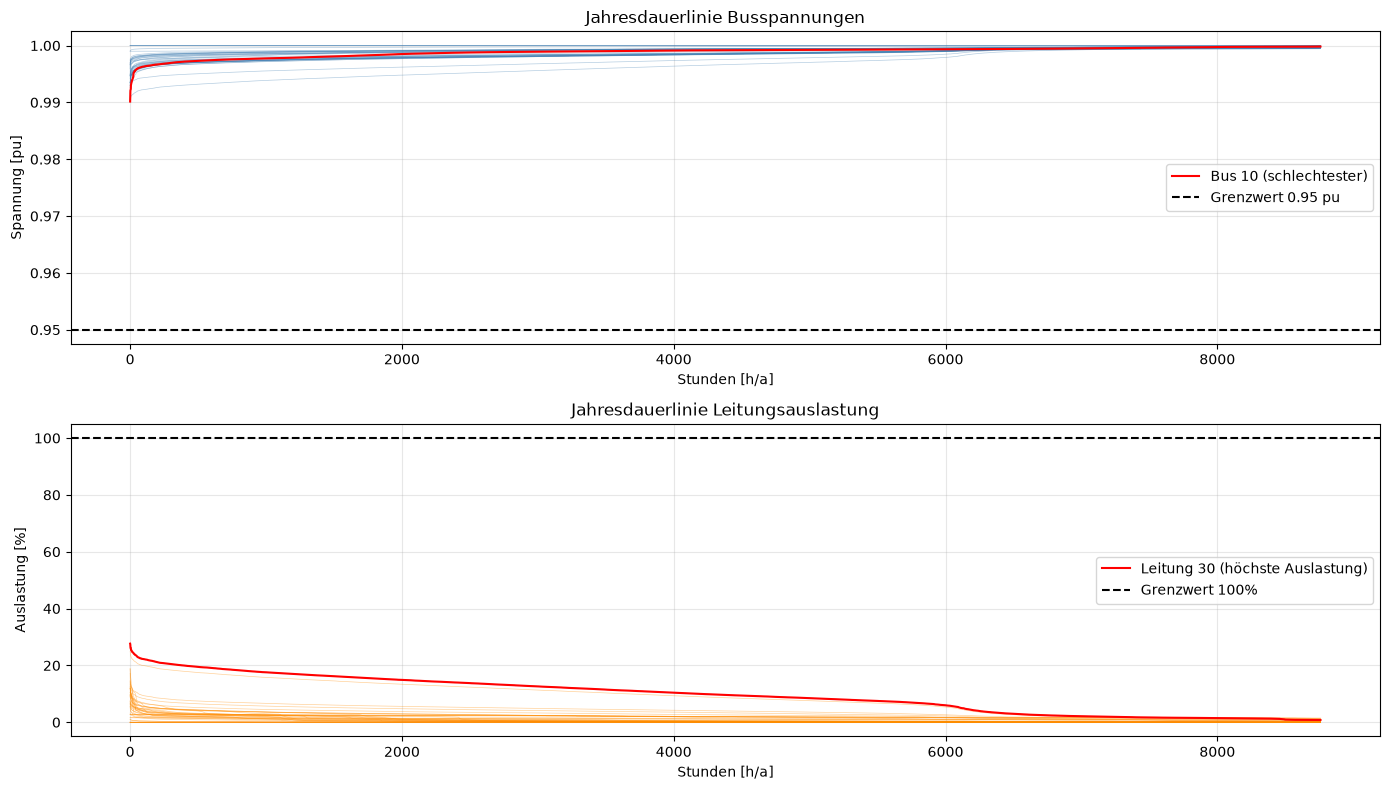

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Jahresdauerlinie Busspannungen ---
for bus in vm_pu_df.columns:
    sortiert = vm_pu_df[bus].sort_values(ascending=True).values
    axes[0].plot(range(8760), sortiert, color="steelblue", linewidth=0.5, alpha=0.4)

# Schlechtester Bus hervorheben
schlechtester = vm_pu_df.min().idxmin()
sortiert_worst = vm_pu_df[schlechtester].sort_values(ascending=True).values
axes[0].plot(range(8760), sortiert_worst, color="red", linewidth=1.5, label=f"Bus {schlechtester} (schlechtester)")
axes[0].axhline(0.95, color="black", linestyle="--", label="Grenzwert 0.95 pu")
axes[0].set_xlabel("Stunden [h/a]")
axes[0].set_ylabel("Spannung [pu]")
axes[0].set_title("Jahresdauerlinie Busspannungen")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Jahresdauerlinie Leitungsauslastung ---
for line in loading_df.columns:
    sortiert = loading_df[line].sort_values(ascending=False).values
    axes[1].plot(range(8760), sortiert, color="darkorange", linewidth=0.5, alpha=0.4)

# Stärkste Leitung hervorheben
stärkste = loading_df.max().idxmax()
sortiert_worst = loading_df[stärkste].sort_values(ascending=False).values
axes[1].plot(range(8760), sortiert_worst, color="red", linewidth=1.5, label=f"Leitung {stärkste} (höchste Auslastung)")
axes[1].axhline(100, color="black", linestyle="--", label="Grenzwert 100%")
axes[1].set_xlabel("Stunden [h/a]")
axes[1].set_ylabel("Auslastung [%]")
axes[1].set_title("Jahresdauerlinie Leitungsauslastung")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()